# 03 · Linear systems and eigenvalues

Discretising almost any engineering field problem - heat conduction, structures, flow networks -
produces a linear system $A\mathbf{x} = \mathbf{b}$.

**Problem.** A 0.1 m thick wall generates heat uniformly ($\dot q$ = 400 kW/m³, e.g. an electrically
heated element) with $k$ = 15 W/(m·K), faces held at 20 °C and 60 °C. Find the temperature profile
from the finite-difference form of $k\,T'' + \dot q = 0$:
$$T_{i-1} - 2T_i + T_{i+1} = -\frac{\dot q\,\Delta x^2}{k}.$$

**What you will learn**

- discretise a 1D boundary-value problem into a linear system
- implement and exploit the tridiagonal (Thomas) algorithm
- solve a 2D problem iteratively and judge convergence correctly
- compute natural frequencies as eigenvalues

**Before you start:** notebook 00; matrices and Gaussian elimination; second derivatives  ·  **Time:** about 60-75 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import linalg

max |error| = 6.25e-13 K  (exact for a quadratic profile)


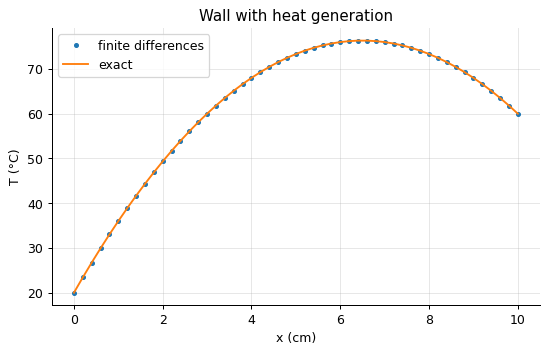

maximum temperature 76.3 °C at x = 6.6 cm


In [2]:
L, k, q, T_left, T_right = 0.1, 15.0, 4e5, 20.0, 60.0
n = 49                                  # interior nodes
x = np.linspace(0, L, n + 2); dx = x[1] - x[0]
lower, diag, upper = np.ones(n), -2*np.ones(n), np.ones(n)
rhs = -q*dx**2/k * np.ones(n)
rhs[0] -= T_left; rhs[-1] -= T_right     # known boundary temperatures move to the right-hand side
T_inner = linalg.thomas(lower, diag, upper, rhs)
T = np.r_[T_left, T_inner, T_right]

T_exact = T_left + (T_right - T_left)*x/L + q/(2*k)*x*(L - x)
print(f"max |error| = {np.max(np.abs(T - T_exact)):.2e} K  (exact for a quadratic profile)")
plt.plot(x*100, T, "o", ms=3, label="finite differences"); plt.plot(x*100, T_exact, label="exact")
plt.xlabel("x (cm)"); plt.ylabel("T (°C)"); plt.legend(); plt.title("Wall with heat generation"); plt.show()
print(f"maximum temperature {T.max():.1f} °C at x = {x[T.argmax()]*100:.1f} cm")

## Inside the algorithm: the Thomas algorithm
Gaussian elimination on a tridiagonal matrix only ever touches three diagonals. A forward sweep
eliminates the lower diagonal; back substitution then solves from the last unknown upwards:

In [3]:
def thomas_by_hand(a, b, c, d):
    # a: lower, b: main, c: upper diagonal (a[0] and c[-1] unused); d: right-hand side
    n = len(d)
    c2, d2 = np.zeros(n), np.zeros(n)
    c2[0], d2[0] = c[0] / b[0], d[0] / b[0]
    for i in range(1, n):                          # forward sweep
        denom = b[i] - a[i] * c2[i-1]
        c2[i] = c[i] / denom if i < n - 1 else 0.0
        d2[i] = (d[i] - a[i] * d2[i-1]) / denom
    x = np.zeros(n)
    x[-1] = d2[-1]
    for i in range(n - 2, -1, -1):                 # back substitution
        x[i] = d2[i] - c2[i] * x[i+1]
    return x

print("max difference from the library:", np.max(np.abs(thomas_by_hand(lower, diag, upper, rhs) - T_inner)))

max difference from the library: 0.0


## Why the Thomas algorithm matters
The matrix is **tridiagonal**. General Gaussian elimination costs $O(n^3)$ operations; the Thomas
algorithm exploits the structure and costs $O(n)$.

In [4]:
import time
for n in (100, 200, 400):
    A = np.diag(-2*np.ones(n)) + np.diag(np.ones(n-1), 1) + np.diag(np.ones(n-1), -1)
    b = np.ones(n)
    t0 = time.perf_counter(); linalg.gauss_solve(A, b); t_g = time.perf_counter() - t0
    t0 = time.perf_counter(); linalg.thomas(np.ones(n), -2*np.ones(n), np.ones(n), b); t_t = time.perf_counter() - t0
    print(f"n = {n:>4}: Gauss {t_g*1e3:7.1f} ms   Thomas {t_t*1e3:5.2f} ms")

n =  100: Gauss     2.1 ms   Thomas  0.14 ms
n =  200: Gauss     8.4 ms   Thomas  0.24 ms
n =  400: Gauss    59.0 ms   Thomas  0.48 ms


## 2D conduction by Gauss-Seidel iteration
For a square plate, direct solution gets expensive; iterative methods repeatedly replace each node
by the average of its neighbours (Laplace's equation) until nothing changes.

after 200 sweeps the change per sweep is 4.7e-02 but the centre is only 20.82 °C
converged after 1388 sweeps; centre temperature 25.0000 °C (exact 25 °C by symmetry)


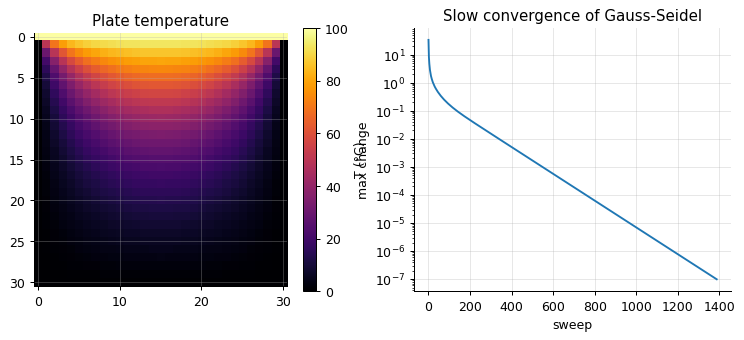

In [5]:
N = 31                                       # odd, so a true centre node exists
Tp = np.zeros((N, N)); Tp[0, :] = 100.0      # hot top edge, other edges at 0 °C
history, centre_early = [], None
for sweep in range(5000):
    old = Tp.copy()
    for i in range(1, N-1):
        for j in range(1, N-1):
            Tp[i, j] = 0.25*(Tp[i+1, j] + Tp[i-1, j] + Tp[i, j+1] + Tp[i, j-1])
    change = np.max(np.abs(Tp - old)); history.append(change)
    if change < 1e-7:
        break
    if sweep == 199:
        centre_early = Tp[N//2, N//2]
print(f"after 200 sweeps the change per sweep is {history[199]:.1e} but the centre is only {centre_early:.2f} °C")
print(f"converged after {sweep + 1} sweeps; centre temperature {Tp[N//2, N//2]:.4f} °C (exact 25 °C by symmetry)")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.8))
im = a1.imshow(Tp, cmap="inferno"); fig.colorbar(im, ax=a1, label="T (°C)"); a1.set_title("Plate temperature")
a2.semilogy(history); a2.set(xlabel="sweep", ylabel="max change", title="Slow convergence of Gauss-Seidel")
plt.show()

By symmetry (superpose the four rotations of the problem) the centre must be exactly 25 °C, even on
the discrete grid. Two lessons: Gauss-Seidel needs many sweeps, and **a small change per sweep is
not the same as a small error** - after 200 sweeps each sweep changes the solution only slightly, yet
the centre is still well below 25 °C. Faster alternatives (SOR, multigrid, sparse direct solvers)
exist for large problems.

## Eigenvalues: natural frequencies of a structure
Five equal masses $m$ connected by springs $k$ (ends fixed) vibrate as $M\ddot{\mathbf x} + K\mathbf x = 0$.
Natural frequencies are $\omega = \sqrt{\lambda}$ with $\lambda$ the eigenvalues of $M^{-1}K$.

lowest  frequency   7.13 Hz  (numpy:   7.13 Hz)
highest frequency  26.63 Hz  (numpy:  26.63 Hz)


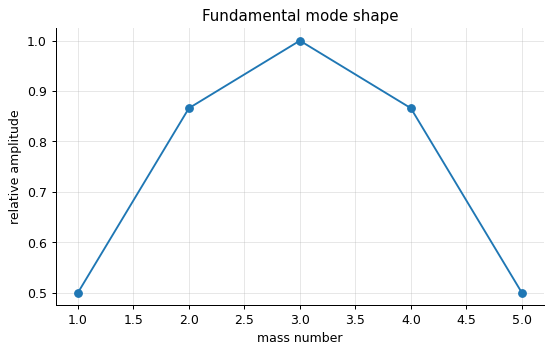

In [6]:
m, ks, nm = 2.0, 1.5e4, 5
K = ks*(2*np.eye(nm) - np.eye(nm, k=1) - np.eye(nm, k=-1))
A = K/m
lam_max, _ = linalg.power_iteration(A)                       # highest mode
lam_min, mode1 = linalg.power_iteration(np.linalg.inv(A))    # inverse iteration -> lowest mode
lam_min = 1/lam_min
all_lam = np.sort(np.linalg.eigvalsh(A))
print(f"lowest  frequency {np.sqrt(lam_min)/(2*np.pi):6.2f} Hz  (numpy: {np.sqrt(all_lam[0])/(2*np.pi):6.2f} Hz)")
print(f"highest frequency {np.sqrt(lam_max)/(2*np.pi):6.2f} Hz  (numpy: {np.sqrt(all_lam[-1])/(2*np.pi):6.2f} Hz)")
plt.plot(range(1, nm+1), mode1/np.max(np.abs(mode1)), "o-"); plt.xlabel("mass number"); plt.ylabel("relative amplitude")
plt.title("Fundamental mode shape"); plt.show()

## Exercises
1. Change the right boundary of the wall to convection, $-k\,T' = h(T - T_\infty)$, with
   $h$ = 25 W/(m²·K) and $T_\infty$ = 20 °C. Only the last equation of the system changes - which one?
2. Solve the 2D plate with Jacobi iteration and compare the number of sweeps with Gauss-Seidel.
3. For the mass-spring chain, how do the frequencies change if the middle mass is doubled?
4. **Implement it yourself:** add successive over-relaxation (SOR) to the 2D plate loop: compute the Gauss-Seidel value $T_{GS}$, then set $T \leftarrow T + \omega(T_{GS} - T)$. Find the $\omega$ between 1.0 and 1.95 that needs the fewest sweeps.